# 2021 Momentum Analysis: Predicting the 2022 Surge
**Objective:** Identify signals in 2021 that could have foreshadowed the 12% revenue leap in 2022. We look at Q4 momentum and post-lockdown recovery speed.

Monthly Revenue Growth within 2021:
Date
2021-01-31          NaN
2021-02-28    42.184719
2021-03-31    71.425628
2021-04-30    19.036036
2021-05-31     6.106495
2021-06-30   -10.219506
2021-07-31   -21.368754
2021-08-31   -32.397019
2021-09-30     9.610165
2021-10-31   -12.225398
2021-11-30   -22.915435
2021-12-31    -0.463262
Freq: ME, Name: Revenue, dtype: float64

Q4 2020 vs Q4 2021 Growth: 5.83%


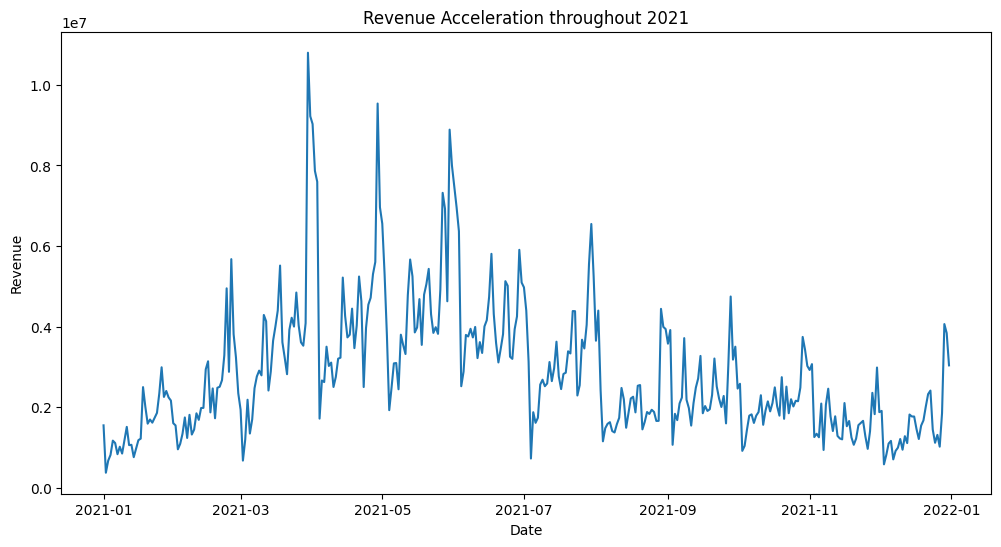

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.config import Config

sales = pd.read_parquet(Config.PROCESSED_DATA_DIR / "sales.parquet")
sales['Date'] = pd.to_datetime(sales['Date'])

# Calculate Monthly Revenue for 2021
sales_21 = sales[sales['Date'].dt.year == 2021].copy()
monthly_21 = sales_21.resample('ME', on='Date')['Revenue'].sum()

print("Monthly Revenue Growth within 2021:")
print(monthly_21.pct_change() * 100)

# Compare Q4 2021 with Q4 2020
q4_21 = sales[(sales['Date'] >= '2021-10-01') & (sales['Date'] <= '2021-12-31')]['Revenue'].sum()
q4_20 = sales[(sales['Date'] >= '2020-10-01') & (sales['Date'] <= '2020-12-31')]['Revenue'].sum()
q4_growth = (q4_21 / q4_20 - 1) * 100

print(f"\nQ4 2020 vs Q4 2021 Growth: {q4_growth:.2f}%")

# Visualizing the acceleration
plt.figure(figsize=(12, 6))
sns.lineplot(data=sales[sales['Date'].dt.year == 2021], x='Date', y='Revenue')
plt.title("Revenue Acceleration throughout 2021")
plt.show()